# Image classification models
## Dependencies

In [6]:
%%capture
!cmd /c dependencies.bat 

### Imports


In [7]:
import tensorflow as tf
print("Dispositivos GPU:", tf.config.list_physical_devices('GPU'))

Dispositivos GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import random
from collections import defaultdict
import pickle
import torch
import time

In [9]:
from skimage import io
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import multilabel_confusion_matrix, f1_score, classification_report

In [10]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras import layers, Sequential
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import ConvLSTM2D, BatchNormalization, Conv2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input

In [11]:
from functions import *
import cv2

In [12]:
random.seed(42)
tf.random.set_seed(42)

## Data


In [13]:
path_capturasVR = "../capturas/capturas_256x256/capturasVR"

In [14]:
database = os.listdir(path_capturasVR)
data_img_labels = database[0]
imgs = database[1:]
print(database)
print(imgs)

['database.csv', 'Session_001', 'Session_002', 'Session_003', 'Session_004', 'Session_005', 'Session_006', 'Session_007', 'Session_008', 'Session_009', 'Session_010', 'Session_011', 'Session_012', 'Session_013', 'Session_014', 'Session_015', 'Session_016', 'Session_017']
['Session_001', 'Session_002', 'Session_003', 'Session_004', 'Session_005', 'Session_006', 'Session_007', 'Session_008', 'Session_009', 'Session_010', 'Session_011', 'Session_012', 'Session_013', 'Session_014', 'Session_015', 'Session_016', 'Session_017']


In [15]:
csv_path = os.path.join(path_capturasVR, data_img_labels)

df = pd.read_csv(csv_path, header =0, names=["filename", "label"])

# Añadir ruta completa a cada imagen
df["full_path"] = df["filename"].apply(lambda x: os.path.join(path_capturasVR, x))

# Separar sesión
df["session"] = df["filename"].str.split("/").str[0]

print(df[["session", "filename", "label"]].head())


       session                      filename        label
0  Session_001  Session_001/capture_0000.png  colocarPila
1  Session_001  Session_001/capture_0001.png  colocarPila
2  Session_001  Session_001/capture_0002.png  colocarPila
3  Session_001  Session_001/capture_0003.png  colocarPila
4  Session_001  Session_001/capture_0004.png  colocarPila


In [16]:
for p in imgs:    
    img_path = os.path.join(path_capturasVR, p)
    print(img_path)

../capturas/capturas_256x256/capturasVR\Session_001
../capturas/capturas_256x256/capturasVR\Session_002
../capturas/capturas_256x256/capturasVR\Session_003
../capturas/capturas_256x256/capturasVR\Session_004
../capturas/capturas_256x256/capturasVR\Session_005
../capturas/capturas_256x256/capturasVR\Session_006
../capturas/capturas_256x256/capturasVR\Session_007
../capturas/capturas_256x256/capturasVR\Session_008
../capturas/capturas_256x256/capturasVR\Session_009
../capturas/capturas_256x256/capturasVR\Session_010
../capturas/capturas_256x256/capturasVR\Session_011
../capturas/capturas_256x256/capturasVR\Session_012
../capturas/capturas_256x256/capturasVR\Session_013
../capturas/capturas_256x256/capturasVR\Session_014
../capturas/capturas_256x256/capturasVR\Session_015
../capturas/capturas_256x256/capturasVR\Session_016
../capturas/capturas_256x256/capturasVR\Session_017


## Auxiliary functions

In [11]:
def show_correct_and_predicted_labels(test_labels, class_names, y_pred_classes, class_ind):
    y_true_class = [i for i, val in enumerate(test_labels) if val == class_ind]
    correct = []
    print(f"Cantidad de imágenes reales de {class_names[class_ind]}: {len(y_true_class)}")
    for idx in y_true_class:
        if y_pred_classes[idx] == class_ind:
            correct.append(idx)
        print(f"Índice: {idx} - Clase real: {class_names[test_labels[idx]]} - Clase predicha: {class_names[y_pred_classes[idx]]}")
    print(f"{len(correct)} clasificaciones correctas para {class_names[class_ind]}: {correct}")
    return correct

In [12]:
def show_image_and_label(images, labels, image_names, num_images=20):
  
    names = np.array(image_names)

    # Mostrar algunas imágenes con etiquetas y nombre
    num_images = min(num_images, len(images))
    fig = plt.figure(figsize=(15, 3 * (num_images // 5 + 1)))
    for i in range(num_images):
        plt.subplot((num_images // 5) + 1, 5, i + 1)
        img = images[i]
        if img.shape[-1] == 1:
            plt.imshow(img.squeeze(), cmap="gray")
        else:
            plt.imshow(img)
        plt.axis("off")
        # Truncar nombre si es muy largo
        name = names[i] if isinstance(names[i], str) else str(names[i])
        display_name = (name[:20] + "...") if len(name) > 22 else name
        title = f"{name}\n{labels[i]}"
        
        plt.title(title, color="red", fontsize=8)

    plt.tight_layout()
    plt.show()

In [13]:
def show_predictions_tf_dataset(model, dataset, encoder, target_class_name=None, num_images=20):
    """
    Extrae imágenes de un tf.data.Dataset, predice y muestra resultados.
    Si target_class_name existe, filtra solo para esa clase.
    """
    all_images = []
    all_labels = []
    all_preds = []

    # 1. Obtener ID de la clase objetivo
    target_idx = encoder.transform([target_class_name])[0] if target_class_name else None

    # 2. Iterar sobre el dataset para recolectar imágenes y predecir
    # (Solo tomamos lo necesario para no agotar la memoria)
    for imgs, labels in dataset:
        preds = model.predict(imgs, verbose=0)
        pred_classes = np.argmax(preds, axis=1)
        
        # Convertir labels de test (que suelen ser indices) a numpy
        labels = labels.numpy()
        
        for i in range(len(labels)):
            # Si hay filtro, verificar si la clase real coincide
            if target_idx is None or labels[i] == target_idx:
                all_images.append(imgs[i].numpy())
                all_labels.append(labels[i])
                all_preds.append(pred_classes[i])
            
            if len(all_images) >= num_images:
                break
        if len(all_images) >= num_images:
            break

    if not all_images:
        print(f"No se encontraron imágenes para la clase: {target_class_name}")
        return

    # 3. Visualización
    num_to_show = len(all_images)
    cols = 5
    rows = (num_to_show // cols) + (1 if num_to_show % cols != 0 else 0)
    
    fig = plt.figure(figsize=(15, 3 * rows))
    
    for i in range(num_to_show):
        plt.subplot(rows, cols, i + 1)
        
        # Re-escalar para mostrar (si es ResNet está en [0,1], si es MobileNet en [-1,1])
        img_display = all_images[i]
        if img_display.min() < 0: # Caso MobileNet [-1, 1]
            img_display = (img_display + 1) / 2
            
        plt.imshow(img_display)
        plt.axis("off")
        
        real_name = encoder.inverse_transform([all_labels[i]])[0]
        pred_name = encoder.inverse_transform([all_preds[i]])[0]
        
        color = "blue" if all_labels[i] == all_preds[i] else "red"
        plt.title(f"Real: {real_name}\nPred: {pred_name}", color=color, fontsize=9)

    plt.tight_layout()
    plt.show()

In [15]:
def show_image_by_index(paths, indexes):

    if indexes == []:
        print("No hay índices")
        return
    for index in indexes:
  
        if index < 0 or index >= len(paths):
            print(f"Índice {index} fuera de rango. El conjunto tiene {len(paths)} imágenes.")
            return
        
        path = paths[index]
        img = plt.imread(path)
        

        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Imagen en índice {index}")
        plt.show()

## Get dataset

In [17]:
(train_paths, train_labels), (val_paths, val_labels), (test_paths, test_labels), encoder = get_paths_and_labels(df, test_size=0.2)

# Pesos para penalizar los errores al clasificar mal la clase minoritaria
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

dict_weights = dict(enumerate(weights))


print(encoder.classes_)
for i, nombre in enumerate(encoder.classes_):
    print(f"ID {i} -> Clase: {nombre}")

print(f"Total: {len(train_paths) + len(val_paths) + len(test_paths)}")
print(f"Entrenamiento: {len(train_paths)}")
print(f"Validación:    {len(val_paths)}")
print(f"Test:          {len(test_paths)}")

print("\nDistribución de clases en el dataset completo:")
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

['colocarNiquel' 'colocarPila' 'colocarSoporteSup' 'soldar']
ID 0 -> Clase: colocarNiquel
ID 1 -> Clase: colocarPila
ID 2 -> Clase: colocarSoporteSup
ID 3 -> Clase: soldar
Total: 7699
Entrenamiento: 4927
Validación:    1232
Test:          1540

Distribución de clases en el dataset completo:
label
colocarPila          3184
soldar               2276
colocarNiquel        2002
colocarSoporteSup     237
Name: count, dtype: int64
label
colocarPila          41.356020
soldar               29.562281
colocarNiquel        26.003377
colocarSoporteSup     3.078322
Name: proportion, dtype: float64


c:\Users\marci\Desktop\tfm\TFM_InteligentTutor\modelos\functions\plottingFunctions.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


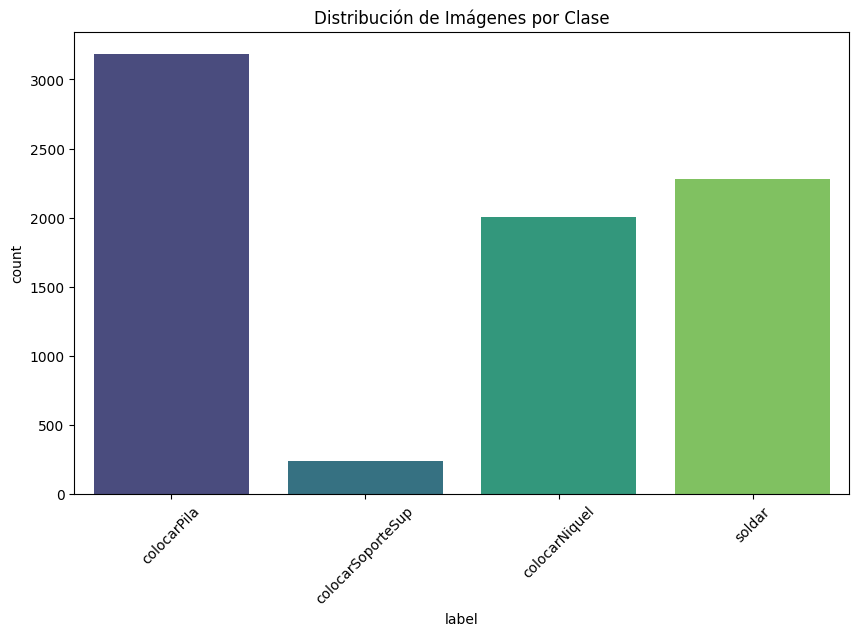

In [18]:
show_class_distribution(df)

In [19]:
def training_pipeline(model, train_ds, val_ds, test_ds, patience=3, epochs=10, lr=0.005):
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=patience, verbose=1, min_lr=4e-10
    )

    early_stop = EarlyStopping(
        monitor='val_loss', 
        patience=patience*2, 
        verbose=1, 
        restore_best_weights=True
    )

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )
        
    history = model.fit(
        train_ds, 
        epochs=epochs, 
        class_weight=dict_weights,
        validation_data=val_ds, 
        callbacks=[lr_callback, early_stop]
    )

    print("\nEvaluando en Entrenamiento...")
    train_loss, train_acc = model.evaluate(train_ds, verbose=0)
    print("Evaluando en Test...")
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)
    
    return test_acc, train_acc, train_loss, test_loss, history

## CNNs

In [26]:
class_names = encoder.classes_ 

### ResNet50

Data augmentation se aplica solo en train porque test y val tienen que representar la realidad

In [ ]:
batch_size = 16

# Crear dataset de entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(len(train_paths)) # Shuffle de rutas
            .map(lambda x, y: load_image_tf(x, y, method="zero_255"), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            .map(augment_if_minority, num_parallel_calls=tf.data.AUTOTUNE) # Aumentar clase minoritaria
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

# Crear dataset de validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
          .map(lambda x, y: load_image_tf(x, y, method="zero_255"), num_parallel_calls=tf.data.AUTOTUNE)
          .batch(batch_size)
          .prefetch(tf.data.AUTOTUNE))

# Crear dataset de test
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = (test_ds
           .map(lambda x, y: load_image_tf(x, y, method="zero_255"), num_parallel_calls=tf.data.AUTOTUNE)
           .batch(batch_size)
           .prefetch(tf.data.AUTOTUNE))

In [ ]:
# from tensorflow.keras.applications.resnet import preprocess_input

# # Crear dataset de entrenamiento
# train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
# train_ds = (train_ds
#             .shuffle(len(train_paths)) # Shuffle de rutas
#             .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
#             .map(augment_if_minority, num_parallel_calls=tf.data.AUTOTUNE) # Aumentar clase minoritaria
#             .map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
#             .batch(batch_size)
#             .prefetch(tf.data.AUTOTUNE))

# # Crear dataset de validación
# val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
# val_ds = (val_ds
#           .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE)
#           .map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
#           .batch(batch_size)
#           .prefetch(tf.data.AUTOTUNE))

# # Crear dataset de test
# test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
# test_ds = (test_ds
#            .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE)
#            .map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
#            .batch(batch_size)
#            .prefetch(tf.data.AUTOTUNE))

In [23]:
base_resnet50 = ResNet50(
    weights = None,
    include_top = False, # whether to include the fully-connected layer at the top of the network.
    input_shape = (256, 256, 3),  # if include_top true input shape must be (224, 224, 3) 
    pooling = "avg"
)

model_resnet50 = Sequential([
    base_resnet50,
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')   # 4 clases
])

epochs = 20

test_acc_resnet50, train_acc_resnet50, train_loss_resnet50, test_loss_resnet50, history_resnet50 = training_pipeline(model_resnet50, train_ds, val_ds, test_ds, epochs=epochs, lr=0.001)
print(f"Test accuracy: {test_acc_resnet50}\nTrain accuracy: {train_acc_resnet50}")
print(f"Test loss: {test_loss_resnet50}\nTrain loss: {train_loss_resnet50}")

Epoch 1/20
308/308 [==============================] - 94s 277ms/step - loss: 0.7207 - accuracy: 0.7542 - val_loss: 12.6588 - val_accuracy: 0.2955 - lr: 0.0010
Epoch 2/20
308/308 [==============================] - 82s 265ms/step - loss: 0.3774 - accuracy: 0.8593 - val_loss: 13.0011 - val_accuracy: 0.3636 - lr: 0.0010
Epoch 3/20
308/308 [==============================] - 120s 391ms/step - loss: 0.2861 - accuracy: 0.9014 - val_loss: 14.8238 - val_accuracy: 0.2873 - lr: 0.0010
Epoch 4/20
308/308 [==============================] - 147s 477ms/step - loss: 0.1593 - accuracy: 0.9391 - val_loss: 0.6714 - val_accuracy: 0.8401 - lr: 0.0010
Epoch 5/20
308/308 [==============================] - 149s 483ms/step - loss: 0.2237 - accuracy: 0.9231 - val_loss: 54.9204 - val_accuracy: 0.2955 - lr: 0.0010
Epoch 6/20
308/308 [==============================] - 151s 489ms/step - loss: 0.2321 - accuracy: 0.9273 - val_loss: 2.8416 - val_accuracy: 0.2646 - lr: 0.0010
Epoch 7/20
308/308 [========================

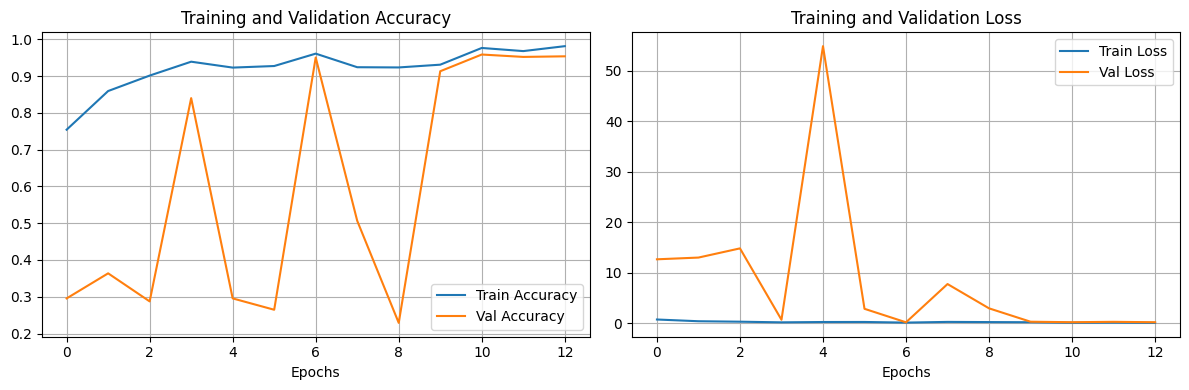

In [24]:
plot_from_history(history_resnet50)

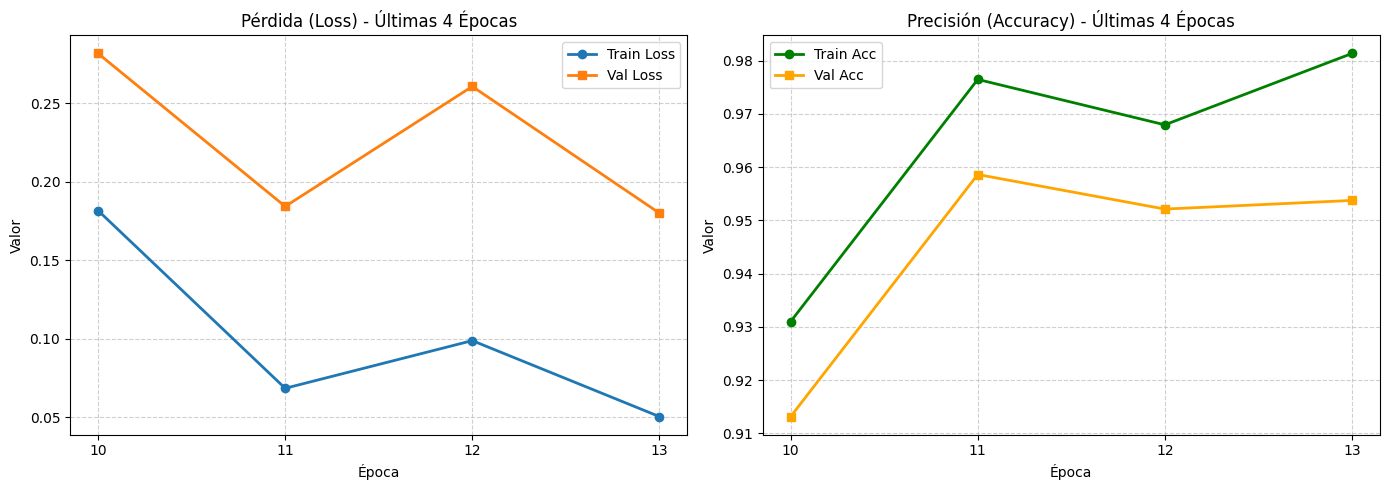

In [25]:
show_last_epochs(history_resnet50, idx = 4)

In [26]:
model_resnet50.save("multiclassModels\modelo_resnet50.h5")
save_history(history_resnet50, "multiclassHistories\history_resnet50.pkl")

In [22]:
model_resnet50 = load_model("multiclassModels\modelo_resnet50.h5")
history_resnet50 = load_history("multiclassHistories\history_resnet50.pkl")

Historial cargado desde multiclassHistories\history_resnet50.pkl.


In [27]:
y_pred_resnet50 = model_resnet50.predict(test_ds)
y_pred_classes_resnet50 = y_pred_resnet50.argmax(axis=1)

f1_resnet50_db = f1_score(test_labels, y_pred_classes_resnet50, average="weighted")
print(f"F1 Score ResNet50 db: {f1_resnet50_db}")
print("-------------------------------------")

print("Classification Report ResNet50 db + no weights:")
print(classification_report(test_labels, y_pred_classes_resnet50, target_names=class_names))

97/97 [==============================] - 11s 100ms/step
F1 Score ResNet50 db: 0.9390676124798922
-------------------------------------
Classification Report ResNet50 db + no weights:
                   precision    recall  f1-score   support

    colocarNiquel       0.89      0.93      0.91       401
      colocarPila       1.00      1.00      1.00       637
colocarSoporteSup       0.45      0.11      0.17        47
           soldar       0.94      0.99      0.96       455

         accuracy                           0.95      1540
        macro avg       0.82      0.75      0.76      1540
     weighted avg       0.94      0.95      0.94      1540



In [42]:
show_multiclass_confusion_matrix(test_labels, y_pred_classes_resnet50, class_names)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1094  | 45    | 30    | 371   |OK
colocarPila          | 901   | 2     | 2     | 635   |OK
colocarSoporteSup    | 1487  | 6     | 42    | 5     |⚠️ >25%
soldar               | 1058  | 27    | 6     | 449   |OK
---------------------------------------------------------------------------


In [52]:
correct_ = show_correct_and_predicted_labels(test_labels, class_names, y_pred_classes_resnet50, 2) # colocarSoporteSup

Cantidad de imágenes reales de colocarSoporteSup: 47
Índice: 28 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 30 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 48 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 211 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 240 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 306 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 342 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 358 - Clase real: colocarSoporteSup - Clase predicha: colocarSoporteSup
Índice: 408 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 412 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 425 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 458 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 460 - Clase real: colocarS

In [53]:
print(correct_)

[358, 716, 809, 1178, 1510]


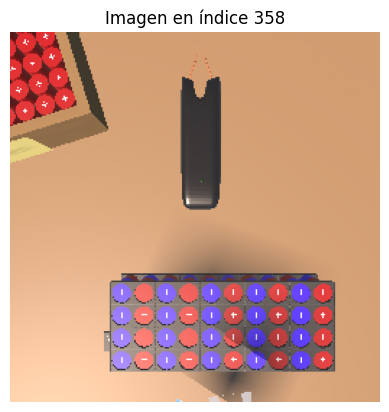

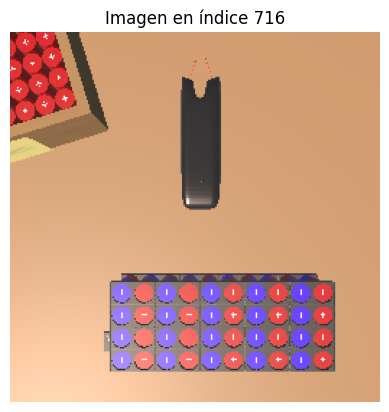

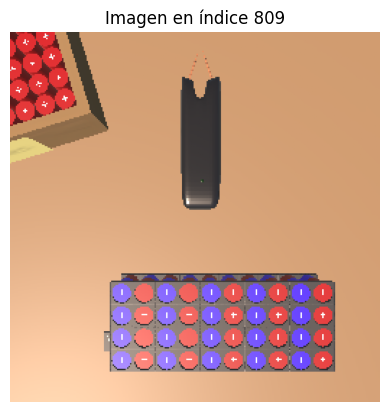

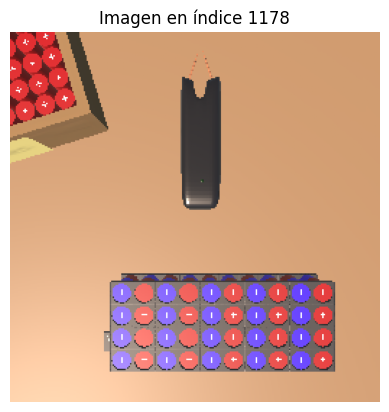

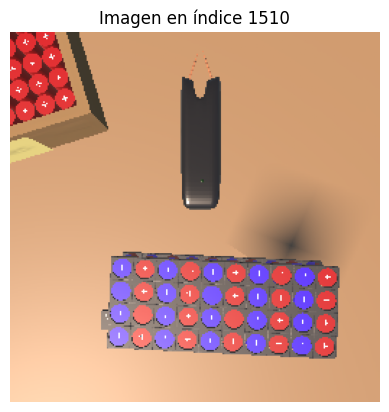

In [ ]:
show_image_by_index(test_paths, correct_)

### EfficientNetB0 - Tensorflow

In [56]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [59]:
batch_size = 16
# Crear dataset de entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(len(train_paths)) # Shuffle de rutas
            .map(lambda x, y: load_image_tf(x, y, method="zero_255"), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            .map(augment_if_minority, num_parallel_calls=tf.data.AUTOTUNE) # Aumentar clase minoritaria
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

# Crear dataset de validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
          .map(lambda x, y: load_image_tf(x, y, method="zero_255"), num_parallel_calls=tf.data.AUTOTUNE)
          .batch(batch_size)
          .prefetch(tf.data.AUTOTUNE))

# Crear dataset de test
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = (test_ds
           .map(lambda x, y: load_image_tf(x, y, method="zero_255"), num_parallel_calls=tf.data.AUTOTUNE)
           .batch(batch_size)
           .prefetch(tf.data.AUTOTUNE))

In [74]:
start_time = time.time()

base_efficientNetB0 = EfficientNetB0(
    include_top = False,
    weights = None,
    input_shape = (256, 256, 3),
    pooling = "avg"  # probar con max
)

model_efficientNetB0 = Sequential([
    base_efficientNetB0,
    layers.Dropout(0.5),  # Dropout para reducir overfitting
    layers.Dense(4, activation='softmax')   # 4 clases
])

epochs = 20

test_acc_efficientNetB0, train_acc_efficientNetB0, train_loss_efficientNetB0, test_loss_efficientNetB0, history_efficientNetB0 = training_pipeline(model_efficientNetB0, train_ds, val_ds, test_ds, patience = 5, epochs=epochs, lr = 0.0001)
print(f"Test accuracy: {test_acc_efficientNetB0}\nTrain accuracy: {train_acc_efficientNetB0}")
print(f"Test loss: {test_loss_efficientNetB0}\nTrain loss: {train_loss_efficientNetB0}")

end_time = time.time()
training_time = end_time - start_time
print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time / 60:.2f} minutos")

Epoch 1/20
308/308 [==============================] - 68s 195ms/step - loss: 0.6607 - accuracy: 0.7171 - val_loss: 2.0296 - val_accuracy: 0.0308 - lr: 1.0000e-04
Epoch 2/20
308/308 [==============================] - 58s 187ms/step - loss: 0.1870 - accuracy: 0.9318 - val_loss: 10.0368 - val_accuracy: 0.0308 - lr: 1.0000e-04
Epoch 3/20
308/308 [==============================] - 97s 316ms/step - loss: 0.1109 - accuracy: 0.9614 - val_loss: 0.3987 - val_accuracy: 0.9481 - lr: 1.0000e-04
Epoch 4/20
308/308 [==============================] - 112s 362ms/step - loss: 0.0897 - accuracy: 0.9700 - val_loss: 0.3452 - val_accuracy: 0.9545 - lr: 1.0000e-04
Epoch 5/20
308/308 [==============================] - 114s 371ms/step - loss: 0.0607 - accuracy: 0.9799 - val_loss: 0.4200 - val_accuracy: 0.9537 - lr: 1.0000e-04
Epoch 6/20
308/308 [==============================] - 118s 382ms/step - loss: 0.0605 - accuracy: 0.9769 - val_loss: 0.4516 - val_accuracy: 0.9481 - lr: 1.0000e-04
Epoch 7/20
308/308 [====

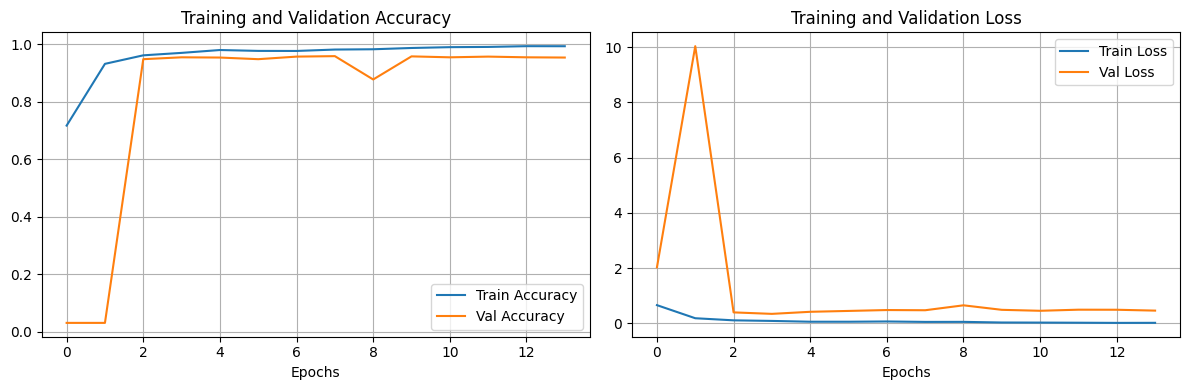

In [76]:
plot_from_history(history_efficientNetB0)

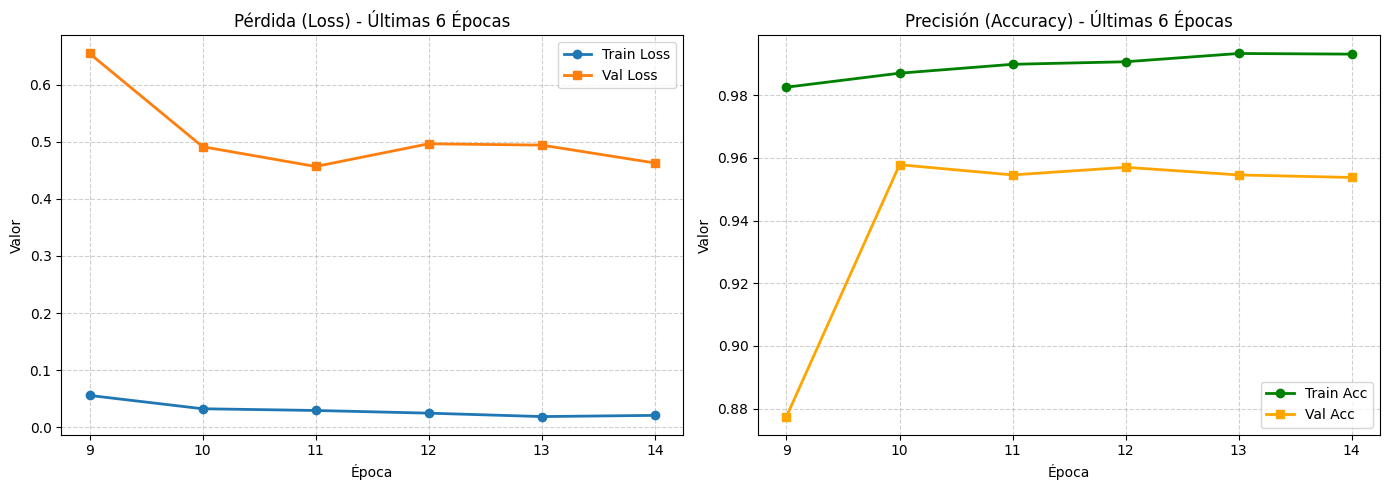

In [77]:
show_last_epochs(history_efficientNetB0, idx = 6)

##### Save model

In [83]:
model_efficientNetB0.save("multiclassModels/modelo_efficientNetB0.h5")
save_history(history_efficientNetB0, "multiclassHistories/history_efficientNetB0.pkl")

##### Load model

In [ ]:
model_efficientNetB0 = load_model("multiclassModels/modelo_efficientNetB0.h5")
history_efficientNetB0 = load_history("multiclassHistories/history_efficientNetB0.pkl")

Historial cargado desde multiclassHistories/history_efficientNetB0.pkl.


#### Test

In [78]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_efficientNetB0 = model_efficientNetB0.predict(test_ds)
y_pred_classes_efficientNetB0 = y_pred_efficientNetB0.argmax(axis=1)

f1_efficientNetB0 = f1_score(y_true, y_pred_classes_efficientNetB0, average="weighted")
print(f"F1 Score EfficientNetB0: {f1_efficientNetB0}")
print("-------------------------------------")

print("Classification Report EfficientNetB0:")
print(classification_report(y_true, y_pred_classes_efficientNetB0, target_names=class_names))

97/97 [==============================] - 8s 73ms/step
F1 Score EfficientNetB0: 0.943034195029445
-------------------------------------
Classification Report EfficientNetB0:
                   precision    recall  f1-score   support

    colocarNiquel       0.88      0.98      0.93       401
      colocarPila       0.99      1.00      1.00       637
colocarSoporteSup       0.00      0.00      0.00        47
           soldar       0.99      0.98      0.98       455

         accuracy                           0.96      1540
        macro avg       0.71      0.74      0.73      1540
     weighted avg       0.93      0.96      0.94      1540



c:\Users\Usuario\miniconda3\envs\tfm_venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Usuario\miniconda3\envs\tfm_venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Usuario\miniconda3\envs\tfm_venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

In [79]:
show_multiclass_confusion_matrix(test_labels, y_pred_classes_efficientNetB0, class_names)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1083  | 56    | 7     | 394   |OK
colocarPila          | 899   | 4     | 1     | 636   |OK
colocarSoporteSup    | 1493  | 0     | 47    | 0     |⚠️ >25%
soldar               | 1079  | 6     | 11    | 444   |OK
---------------------------------------------------------------------------


Hay 4 casos de tipo [FP] para la clase 'colocarPila'


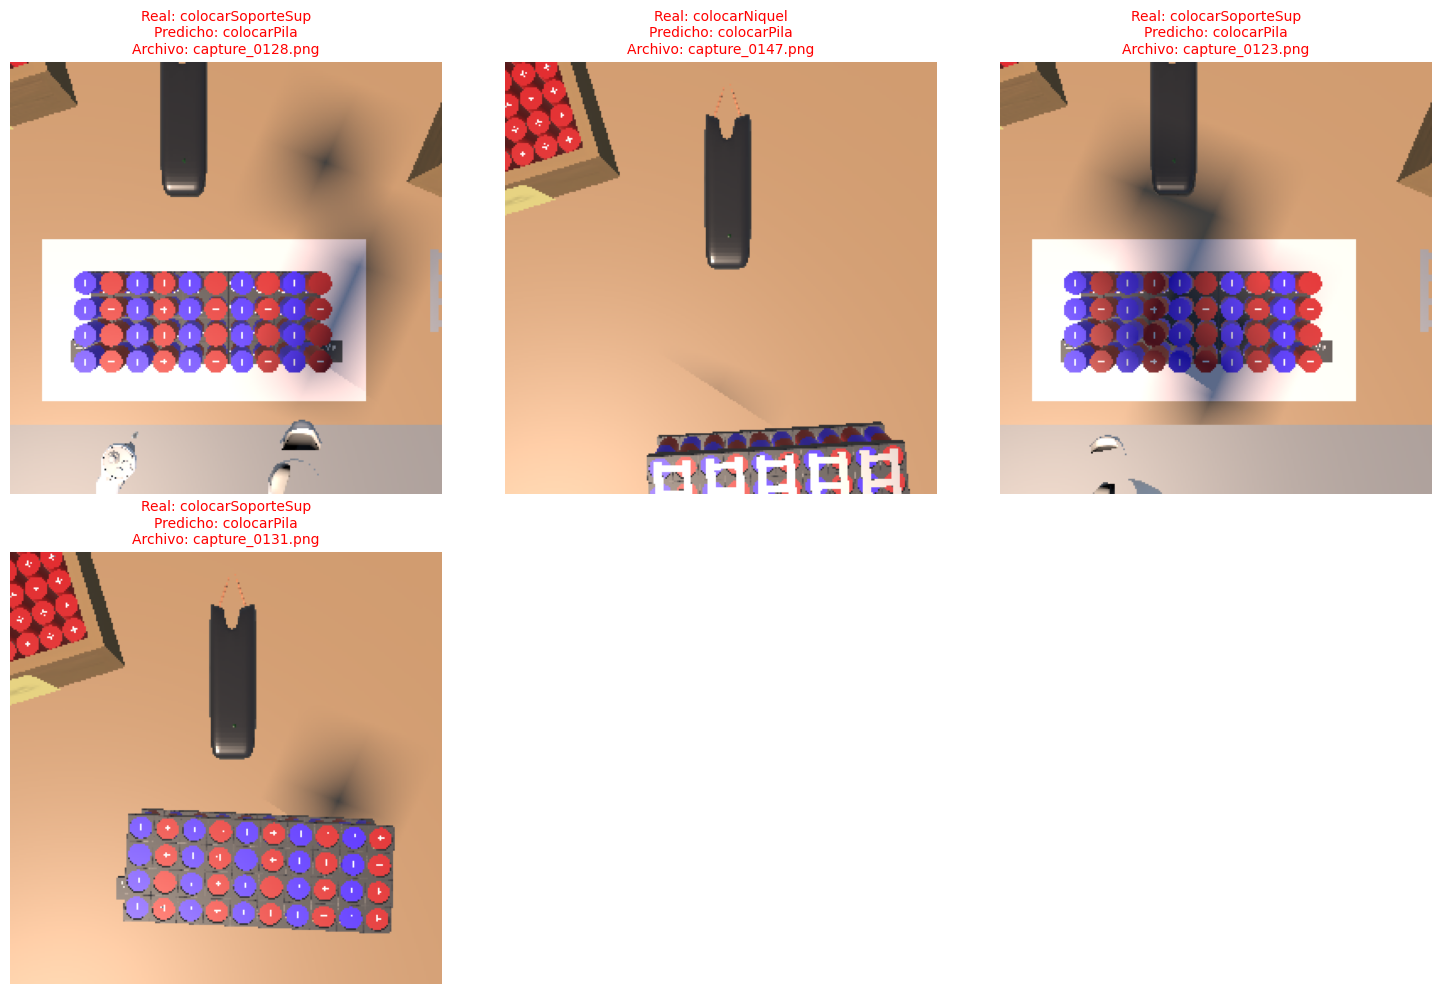

In [82]:
show_imgs(test_paths, y_true, y_pred_classes_efficientNetB0, class_names, clase_nombre="colocarPila", tipo_caso="FP", max_imagenes=48)

### MobileNet

In [29]:
from tensorflow.keras.applications import MobileNet

In [ ]:
batch_size = 32

# Crear dataset de entrenamiento
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(len(train_paths)) # Shuffle de rutas
            .map(lambda x, y: load_image_tf(x, y, method="min_max"), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            .map(augment_if_minority, num_parallel_calls=tf.data.AUTOTUNE) # Aumentar clase minoritaria
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

# Crear dataset de validación
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
          .map(lambda x, y: load_image_tf(x, y, method="min_max"), num_parallel_calls=tf.data.AUTOTUNE)
          .batch(batch_size)
          .prefetch(tf.data.AUTOTUNE))

# Crear dataset de test
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = (test_ds
           .map(lambda x, y: load_image_tf(x, y, method="min_max"), num_parallel_calls=tf.data.AUTOTUNE)
           .batch(batch_size)
           .prefetch(tf.data.AUTOTUNE))

In [40]:
start_time = time.time()

base_mobilenet = MobileNet(
    include_top = False,
    weights = None,
    input_shape = (256, 256, 3),
    pooling = "avg"
)

model_mobilenet = Sequential([
    base_mobilenet,
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')   # 4 clases
])

epochs = 20

test_acc_mobilenet, train_acc_mobilenet, train_loss_mobilenet, test_loss_mobilenet, history_mobilenet = training_pipeline(model_mobilenet, train_ds, val_ds, test_ds, epochs=epochs, lr = 0.0001)
print(f"Test accuracy: {test_acc_mobilenet}\nTrain accuracy: {train_acc_mobilenet}")
print(f"Test loss: {test_loss_mobilenet}\nTrain loss: {train_loss_mobilenet}")

end_time = time.time()
training_time = end_time - start_time
print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time / 60:.2f} minutos")

Epoch 1/20
154/154 [==============================] - 33s 195ms/step - loss: 0.4609 - accuracy: 0.7826 - val_loss: 2.2229 - val_accuracy: 0.0308 - lr: 1.0000e-04
Epoch 2/20
154/154 [==============================] - 29s 188ms/step - loss: 0.0678 - accuracy: 0.9791 - val_loss: 3.9832 - val_accuracy: 0.0308 - lr: 1.0000e-04
Epoch 3/20
154/154 [==============================] - 30s 192ms/step - loss: 0.0353 - accuracy: 0.9907 - val_loss: 6.7750 - val_accuracy: 0.0308 - lr: 1.0000e-04
Epoch 4/20
154/154 [==============================] - ETA: 0s - loss: 0.0273 - accuracy: 0.9919
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
154/154 [==============================] - 30s 191ms/step - loss: 0.0273 - accuracy: 0.9919 - val_loss: 8.5085 - val_accuracy: 0.0308 - lr: 1.0000e-04
Epoch 5/20
154/154 [==============================] - 29s 188ms/step - loss: 0.0221 - accuracy: 0.9931 - val_loss: 6.7899 - val_accuracy: 0.0308 - lr: 5.0000e-05
Epoch 6/20
154/154 [=========

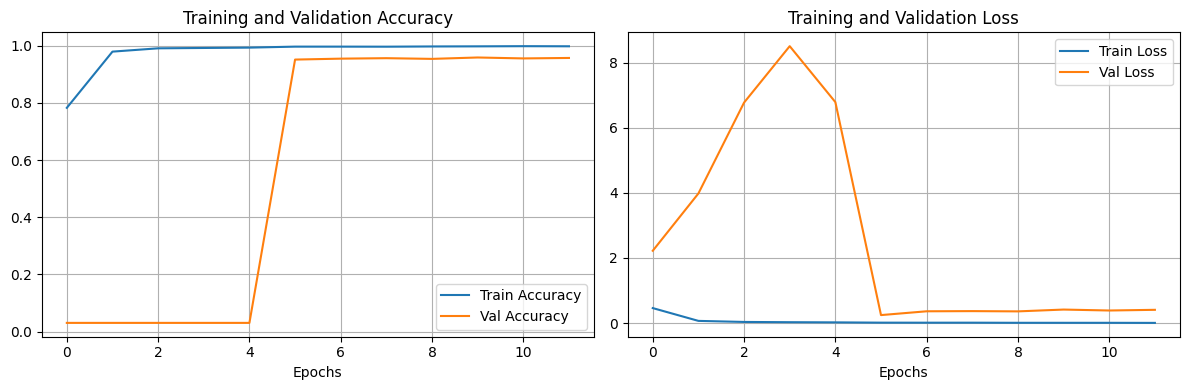

In [42]:
plot_from_history(history_mobilenet)

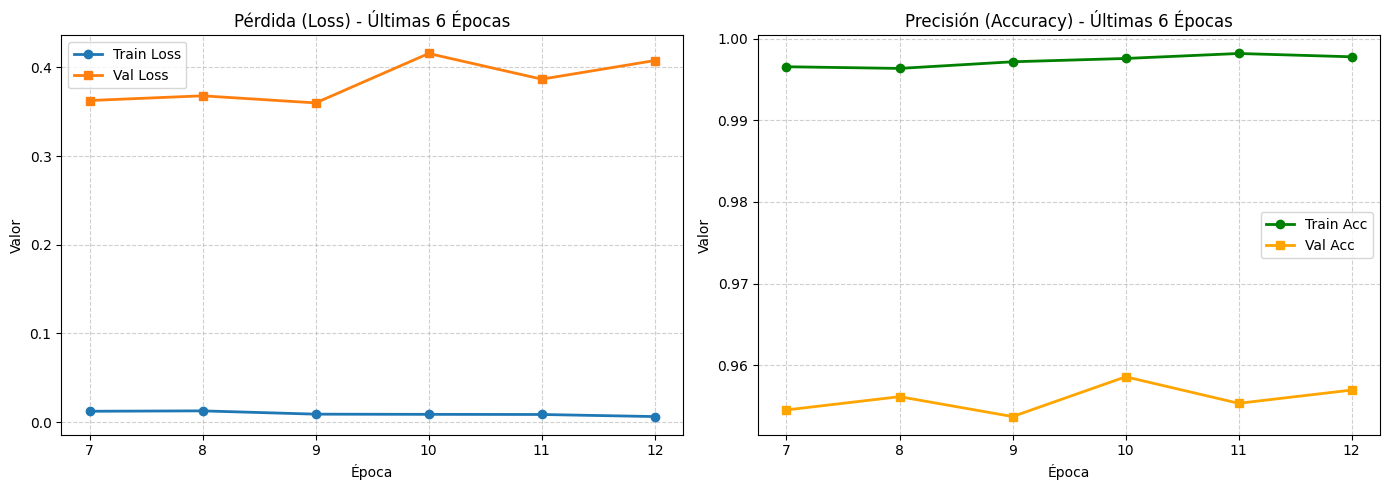

In [43]:
show_last_epochs(history_mobilenet, idx = 6)

In [ ]:
model_mobilenet.save("multiclassModels\model_mobilenet.h5")
save_history(history_mobilenet, "multiclassHistories\history_mobilenet.pkl")

In [ ]:
model_mobilenet = load_model("multiclassModels\model_mobilenet.h5")
history_mobilenet = load_history("multiclassHistories\history_mobilenet.pkl")

Historial cargado desde history_mobilenet.pkl.


In [47]:
y_pred_mobilenet = model_mobilenet.predict(test_ds)
y_pred_classes_mobilenet = y_pred_mobilenet.argmax(axis=1)
class_names = encoder.classes_ 

f1_mobilenet = f1_score(test_labels, y_pred_classes_mobilenet, average="weighted")
print(f"F1 Score MobileNet: {f1_mobilenet}")
print("-------------------------------------")

print("Classification Report MobileNet:")
print(classification_report(test_labels, y_pred_classes_mobilenet, target_names=class_names))

49/49 [==============================] - 2s 47ms/step
F1 Score MobileNet: 0.9421152597814775
-------------------------------------
Classification Report MobileNet:
                   precision    recall  f1-score   support

    colocarNiquel       0.89      0.96      0.92       401
      colocarPila       0.98      1.00      0.99       637
colocarSoporteSup       0.11      0.02      0.04        47
           soldar       0.99      0.98      0.98       455

         accuracy                           0.95      1540
        macro avg       0.74      0.74      0.73      1540
     weighted avg       0.93      0.95      0.94      1540



In [48]:
show_multiclass_confusion_matrix(test_labels, y_pred_classes_mobilenet, class_names)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1092  | 47    | 17    | 384   |OK
colocarPila          | 891   | 12    | 0     | 637   |OK
colocarSoporteSup    | 1485  | 8     | 46    | 1     |⚠️ >25%
soldar               | 1080  | 5     | 9     | 446   |OK
---------------------------------------------------------------------------


In [55]:
show_correct_and_predicted_labels(test_labels, class_names, y_pred_classes_mobilenet, 2) # colocarSoporteSup

Cantidad de imágenes reales de colocarSoporteSup: 47
Índice: 28 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 30 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 48 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 211 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 240 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 306 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 342 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 358 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 408 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 412 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 425 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 458 - Clase real: colocarSoporteSup - Clase predicha: colocarNiquel
Índice: 460 - Clase real: colocarSopor

[1447]

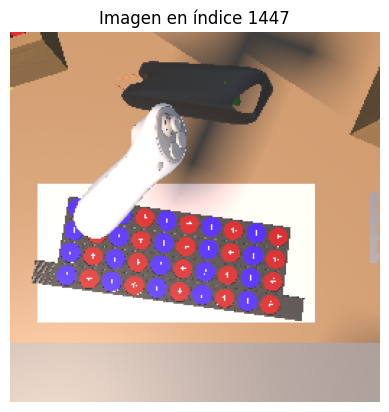

In [56]:
show_image_by_index(test_paths, [1447])

Falsos FP de colocarSoporteSup: 8
=========== Falsos FP de colocarSoporteSup ===========


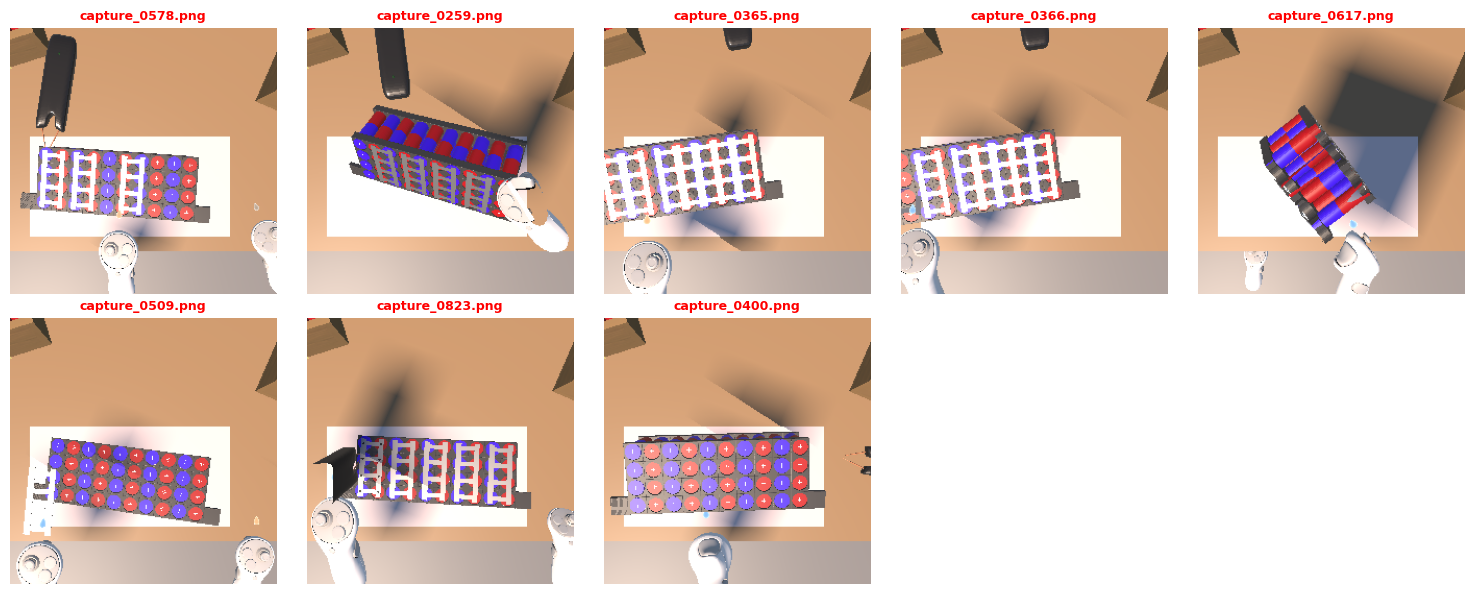

In [54]:
show_false_labels_multiclass(test_labels, test_paths, class_names, y_pred_classes_mobilenet, 2, type='FP') 

### VGG16

In [14]:
from tensorflow.keras.applications import vgg16

In [ ]:
train_ds, val_ds, test_ds = get_dataset(train_paths, train_labels, val_paths, val_labels, test_paths, test_labels, batch_size=16, norm_method="zero_255")

In [16]:
batch_size = 16

# --- DATASET DE ENTRENAMIENTO ---
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = (train_ds
            .shuffle(len(train_paths))
            .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            .map(augment_if_minority, num_parallel_calls=tf.data.AUTOTUNE) # Aumento de datos
            .map(lambda x, y: (vgg16.preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

# --- DATASET DE VALIDACIÓN ---
val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
val_ds = (val_ds
            .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            .map(lambda x, y: (vgg16.preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))

# --- DATASET DE TEST ---
test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_ds = (test_ds
            .map(lambda x, y: load_image_tf(x, y, method=None), num_parallel_calls=tf.data.AUTOTUNE) # Carga paralela
            .map(lambda x, y: (vgg16.preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
            .batch(batch_size)
            .prefetch(tf.data.AUTOTUNE))


In [17]:
start_time = time.time()

base_vgg16 = vgg16.VGG16(
    include_top = False,
    weights = "imagenet",
    input_shape = (256, 256, 3),
    pooling = "avg"
)

model_vgg16 = Sequential([
    base_vgg16,
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')   # 4 clases
])

epochs = 20

test_acc_vgg16, train_acc_vgg16, train_loss_vgg16, test_loss_vgg16, history_vgg16 = training_pipeline(model_vgg16, train_ds, val_ds, test_ds, epochs=epochs)
print(f"Test accuracy: {test_acc_vgg16}\nTrain accuracy: {train_acc_vgg16}")
print(f"Test loss: {test_loss_vgg16}\nTrain loss: {train_loss_vgg16}")

end_time = time.time()
training_time = end_time - start_time
print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time / 60:.2f} minutos")

58889256/58889256 [==============================] - 4s 0us/step
Epoch 1/20
308/308 [==============================] - 172s 488ms/step - loss: 1044672.6875 - accuracy: 0.1938 - val_loss: 1.4368 - val_accuracy: 0.0308 - lr: 0.0050
Epoch 2/20
308/308 [==============================] - 131s 425ms/step - loss: 1.3895 - accuracy: 0.1660 - val_loss: 1.3775 - val_accuracy: 0.2597 - lr: 0.0050
Epoch 3/20
308/308 [==============================] - 131s 424ms/step - loss: 1.3877 - accuracy: 0.1953 - val_loss: 1.3876 - val_accuracy: 0.2597 - lr: 0.0050
Epoch 4/20
308/308 [==============================] - 163s 529ms/step - loss: 1.3877 - accuracy: 0.1581 - val_loss: 1.3778 - val_accuracy: 0.4140 - lr: 0.0050
Epoch 5/20
308/308 [==============================] - ETA: 0s - loss: 1.3879 - accuracy: 0.3132
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0024999999441206455.
308/308 [==============================] - 196s 636ms/step - loss: 1.3879 - accuracy: 0.3132 - val_loss: 1.3846 - val_acc

In [29]:
model_vgg16.save("multiclassModels\modelo_vgg16.h5")
save_history(history_vgg16, "multiclassHistories\history_vgg16.pkl")

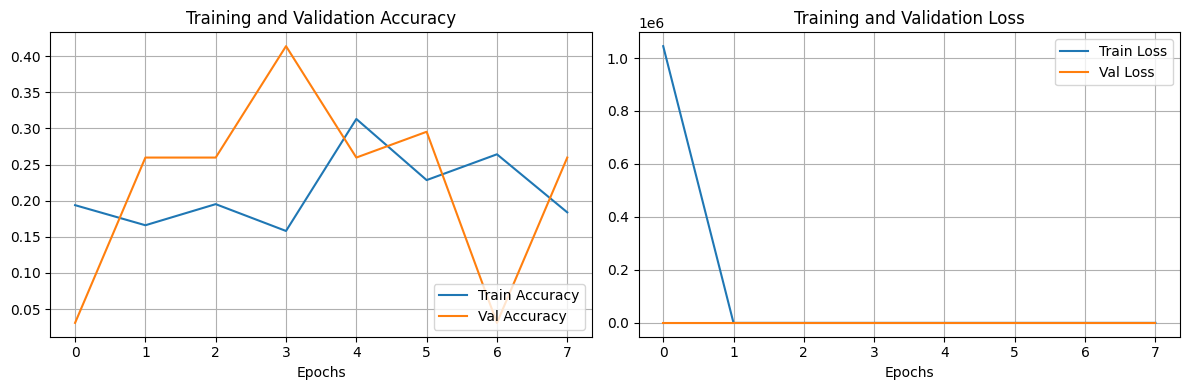

In [18]:
plot_from_history(history_vgg16)

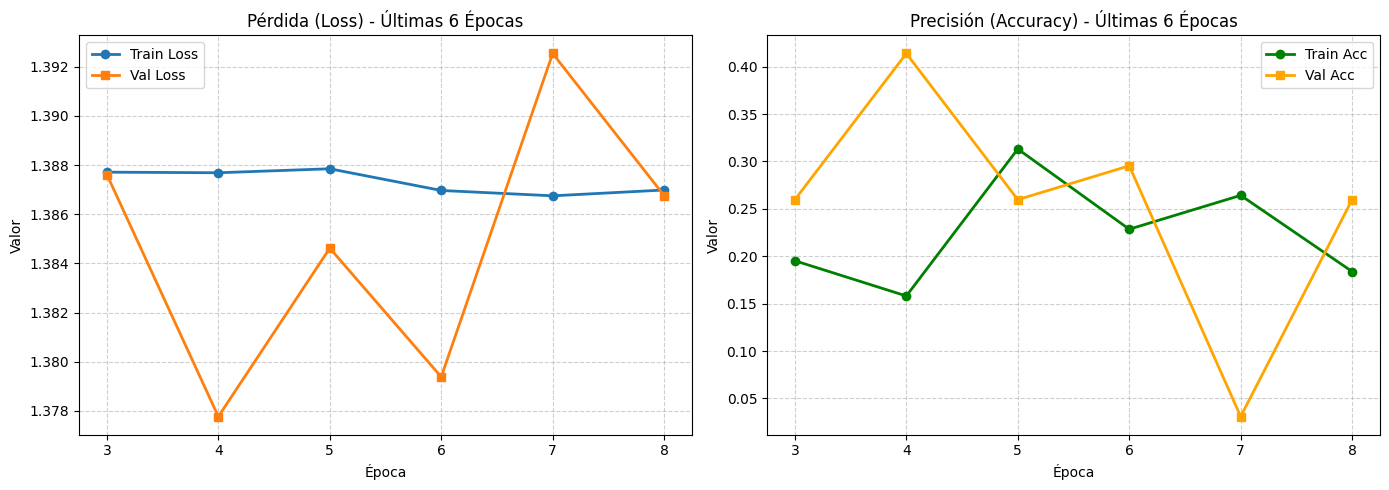

In [19]:
show_last_epochs(history_vgg16, idx = 6)

In [21]:
y_pred_vgg16 = model_vgg16.predict(test_ds)
y_pred_classes_vgg16 = y_pred_vgg16.argmax(axis=1)
class_names = encoder.classes_ 

f1_vgg16 = f1_score(test_labels, y_pred_classes_vgg16, average="weighted")
print(f"F1 Score vgg16: {f1_vgg16}")
print("-------------------------------------")

print("Classification Report vgg16:")
print(classification_report(test_labels, y_pred_classes_vgg16, target_names=class_names))

97/97 [==============================] - 10s 97ms/step
F1 Score vgg16: 0.10759014298426972
-------------------------------------
Classification Report vgg16:
                   precision    recall  f1-score   support

    colocarNiquel       0.26      1.00      0.41       401
      colocarPila       0.00      0.00      0.00       637
colocarSoporteSup       0.00      0.00      0.00        47
           soldar       0.00      0.00      0.00       455

         accuracy                           0.26      1540
        macro avg       0.07      0.25      0.10      1540
     weighted avg       0.07      0.26      0.11      1540



c:\Users\Usuario\miniconda3\envs\tfm_venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Usuario\miniconda3\envs\tfm_venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Usuario\miniconda3\envs\tfm_venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

In [22]:
show_multiclass_confusion_matrix(test_labels, y_pred_classes_vgg16, class_names)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 0     | 1139  | 0     | 401   | >25%
colocarPila          | 903   | 0     | 637   | 0     | >25%
colocarSoporteSup    | 1493  | 0     | 47    | 0     | >25%
soldar               | 1085  | 0     | 455   | 0     | >25%
---------------------------------------------------------------------------


## SVMs
SVC, NuSVC and LinearSVC are classes capable of performing binary and multi-class classification on a dataset.

In [21]:
def prepare_data_for_svm(paths, labels, size=(256, 256), gray=False):
    x = []
    y = []
    
    for path, label in zip(paths, labels):
        img = cv2.imread(path)
        if gray:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)  # Convertir a escala de grises
        img = cv2.resize(img, size)
        x.append(img.flatten())  # Aplanar la imagen a un vector
        y.append(label)  # Obtener la etiqueta correspondiente
    
    return np.array(x), np.array(y)

In [29]:
(paths, labels), encoder = get_paths_and_labels(df, split=False)

In [31]:
class_names = encoder.classes_

In [30]:
x, y = prepare_data_for_svm(paths, labels, size=(170, 170), gray=True)

### SVC 
C-Support Vector Classification.


In [20]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV 
from sklearn.decomposition import PCA

- C: Controls the trade-off between a wider margin (low C) and correctly classifying all points (high C).
- gamma: Controls the influence of data points. High gamma leads to a tight boundary and may cause overfitting.
- kernel: Defines the function used to transform data for separating classes. 





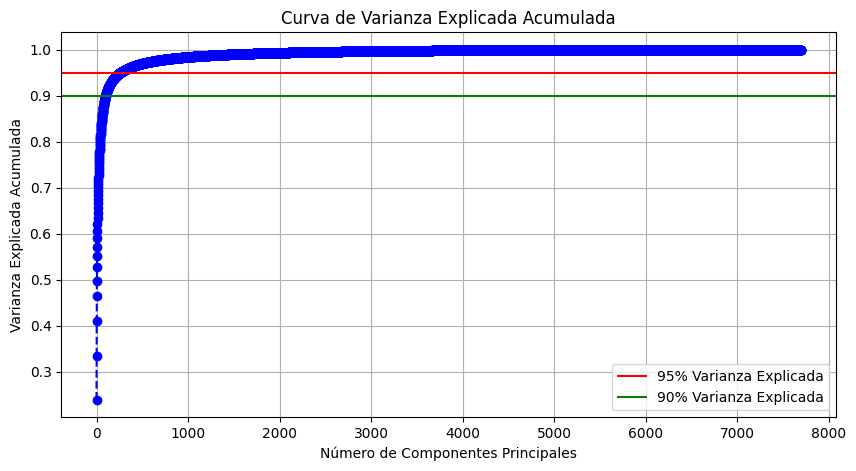

Para retener el 95% de la varianza necesitas: 260 componentes.


In [32]:
pca_full = PCA().fit(x)

variance_cumsum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(variance_cumsum, marker='o', linestyle='--', color='b')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Varianza Explicada')
plt.axhline(y=0.90, color='g', linestyle='-', label='90% Varianza Explicada')

plt.title('Curva de Varianza Explicada Acumulada')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.legend()
plt.show()

components_95 = np.argmax(variance_cumsum >= 0.95) + 1
print(f"Para retener el 95% de la varianza necesitas: {components_95} componentes.")

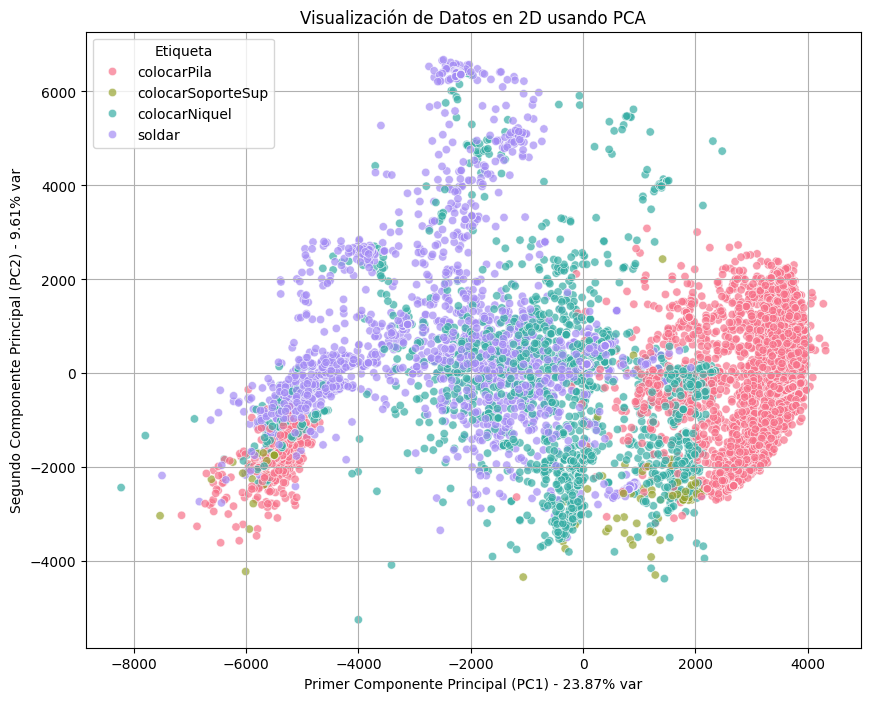

In [33]:
# PCA con dos componentes para graficar
pca_2d = PCA(n_components=2)
x_train_pca_2d = pca_2d.fit_transform(x)

df_pca = pd.DataFrame(x_train_pca_2d, columns=['PC1', 'PC2'])
df_pca['Etiqueta'] = class_names[y]

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2', 
    hue='Etiqueta', 
    palette='husl',  
    data=df_pca, 
    alpha=0.7
)

# porcentajes de varianza que representan esos dos ejes
var_pc1 = pca_2d.explained_variance_ratio_[0] * 100
var_pc2 = pca_2d.explained_variance_ratio_[1] * 100

plt.title('Visualización de Datos en 2D usando PCA')
plt.xlabel(f'Primer Componente Principal (PC1) - {var_pc1:.2f}% var')
plt.ylabel(f'Segundo Componente Principal (PC2) - {var_pc2:.2f}% var')
plt.grid(True)
plt.show()

In [34]:
x_pca = PCA(n_components=components_95).fit_transform(x)

In [35]:
x_train, x_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.2, random_state=42)

In [42]:
param_grid = {'C': [0.1, 1, 10, 100], 
			'gamma': [0.01, 0.001, 0.0001], 
			'kernel': ['rbf']} 

grid = GridSearchCV(SVC(), param_grid, refit = True, verbose = 3, n_jobs=-1) 
 
grid.fit(x_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


GridSearchCV(estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10, 100], 'gamma': [0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [43]:
y_pred_svm = grid.predict(x_test)

f1_svm = f1_score(y_test, y_pred_svm, average="weighted")
print(f"F1 Score SVM: {f1_svm}")
print("-------------------------------------")

print("Classification Report SVM:")
print(classification_report(y_test, y_pred_svm, target_names=class_names))

F1 Score SVM: 0.41141186569573807
-------------------------------------
Classification Report SVM:
                   precision    recall  f1-score   support

    colocarNiquel       0.96      0.15      0.27       422
      colocarPila       0.45      1.00      0.62       617
colocarSoporteSup       1.00      0.51      0.67        55
           soldar       0.98      0.13      0.23       446

         accuracy                           0.50      1540
        macro avg       0.85      0.45      0.45      1540
     weighted avg       0.76      0.50      0.41      1540



In [44]:
show_multiclass_confusion_matrix(y_test, y_pred_svm, class_names)

=== MATRICES DE CONFUSIÓN POR CLASE ===
Clase                | TN    | FP    | FN    | TP    | Estado         
---------------------------------------------------------------------------
colocarNiquel        | 1115  | 3     | 357   | 65    | >25%
colocarPila          | 156   | 767   | 0     | 617   | >25%
colocarSoporteSup    | 1485  | 0     | 27    | 28    | >25%
soldar               | 1093  | 1     | 387   | 59    | >25%
---------------------------------------------------------------------------


In [46]:
import joblib
joblib.dump(grid, "multiclassModels\modelo_svm.pkl")

['multiclassModels\\modelo_svm.pkl']

In [ ]:
historial_svm = pd.DataFrame(grid.cv_results_)

historial_svm = historial_svm.sort_values(by='mean_test_score', ascending=False)

columnas_interes = ['param_C', 'param_gamma', 'mean_test_score', 'std_test_score', 'mean_fit_time']
print(historial_svm[columnas_interes].head())

    param_C  param_gamma  mean_test_score  std_test_score  mean_fit_time
8      10.0       0.0001         0.511610        0.002764      31.459429
11    100.0       0.0001         0.511610        0.002764      30.849387
5       1.0       0.0001         0.509012        0.003021      30.527184
7      10.0       0.0010         0.496023        0.003579      31.175892
10    100.0       0.0010         0.496023        0.003579      30.930669
